In [1]:
import xarray as xr
import pandas as pd
import sqlalchemy
import pygrib
import sqlite3

import numpy as np
from pathlib import Path

import numpy as np



In [2]:


# ----------------------------
# CONFIG
# ----------------------------

GRIB_FOLDER = Path("/home/joe/work/Fire/ML/Data")
DB_PATH_U = f"/home/joe/work/Fire/ML/Data/DB/era5_daily_2982_10u.sqlite"
DB_PATH_V = f"/home/joe/work/Fire/ML/Data/DB/era5_daily_2982_10v.sqlite"
DB_LATLONS = "/home/joe/work/Fire/ML/Data/DB/era5_latlons_2982.sqlite"
DB_PATH_WS = f"/home/joe/work/Fire/ML/Data/DB/era5_daily_2982_10ws.sqlite"
connu = sqlite3.connect(DB_PATH_U)
connv = sqlite3.connect(DB_PATH_V)
connws = sqlite3.connect(DB_PATH_WS)



In [4]:
for yr in range(1990,2026):
    print(f"Processing year {yr}...")
    start=f"{yr}0101"
    end=f"{yr}1231"   
    dfU= pd.read_sql_query(f"SELECT * FROM daily_data where datetime >= {start} and datetime <= {end}", connu)
    dfV= pd.read_sql_query(f"SELECT * FROM daily_data where datetime >= {start} and datetime <= {end}", connv)
    ws= dfU[["datetime","point_id"]].copy()

    ws['0'] = np.sqrt(dfU['0']**2 + dfV['0']**2)
    ws['3'] = np.sqrt(dfU['3']**2 + dfV['3']**2)
    ws['6'] = np.sqrt(dfU['6']**2 + dfV['6']**2)
    ws['9'] = np.sqrt(dfU['9']**2 + dfV['9']**2)
    ws['12'] = np.sqrt(dfU['12']**2 + dfV['12']**2)
    ws['15'] = np.sqrt(dfU['15']**2 + dfV['15']**2)
    ws['18'] = np.sqrt(dfU['18']**2 + dfV['18']**2)
    ws['21'] = np.sqrt(dfU['21']**2 + dfV['21']**2)
    ws.to_sql('daily_data',connws, index=False, if_exists='append')

connu.close()
connv.close()
connws.close()

Processing year 1990...
Processing year 1991...
Processing year 1992...
Processing year 1993...
Processing year 1994...
Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


In [31]:
ws = pd.read_sql_query(f"SELECT * FROM daily_data", connws)     

In [9]:
ws.groupby("point_id")[['0', '3', '6', '9', '12', '15', '18', '21']].mean()

,0,3,6,9,12,15,18,21
point_id,,,,,,,,
0,3.560614,2.593394,2.264582,2.079473,2.009717,2.311896,3.471129,3.936664
1,3.782697,2.794791,2.484334,2.292077,2.215714,2.509748,3.684241,4.170237
2,4.031946,3.035989,2.744488,2.551575,2.471692,2.739355,3.914016,4.421326
3,4.229930,3.231429,2.954045,2.758215,2.667095,2.911418,4.089448,4.623963
4,4.372179,3.375528,3.107054,2.902587,2.791752,3.021757,4.208723,4.774927
...,...,...,...,...,...,...,...,...
2977,4.594035,4.427400,4.413630,4.255953,4.117887,4.456287,4.923368,5.068960
2978,4.546661,4.419990,4.414221,4.243105,4.101385,4.444426,4.903764,5.035304
2979,4.477935,4.382204,4.390301,4.206123,4.058062,4.411933,4.870809,4.991202


In [6]:
print(ws.isna().sum())
print(ws.shape)

datetime    0
point_id    0
0           0
3           0
6           0
9           0
12          0
15          0
18          0
21          0
dtype: int64
(37301838, 10)


In [32]:
wsmn = ws[['datetime','point_id']]

In [33]:
wsmn['mean'] = ws[['0', '3', '6', '9', '12', '15', '18', '21']].mean(axis=1)

/tmp/ipykernel_39210/1262181717.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wsmn['mean'] = ws[['0', '3', '6', '9', '12', '15', '18', '21']].mean(axis=1)


In [6]:
wsmn.describe()

,point_id,mean
count,3.730184e+07,3.730184e+07
mean,1.490500e+03,2.731354e+00
std,8.608292e+02,1.512071e+00
min,0.000000e+00,1.042385e-01
25%,7.450000e+02,1.609823e+00
50%,1.490500e+03,2.331692e+00
75%,2.236000e+03,3.502911e+00
max,2.981000e+03,1.644344e+01


In [19]:
dfup = wsmn.loc[wsmn['mean'] >= 3.5]
dfup['mean'].mean()

np.float64(4.854354007033108)

In [16]:
dfup2 = dfup.loc[dfup['mean'] >= dfup['mean'].mean()]

In [17]:
dfup2.describe()

,point_id,mean
count,3.531959e+06,3.531959e+06
mean,1.481105e+03,6.118743e+00
std,9.395171e+02,1.194659e+00
min,0.000000e+00,4.854355e+00
25%,5.660000e+02,5.230368e+00
50%,1.490000e+03,5.754231e+00
75%,2.390000e+03,6.645513e+00
max,2.981000e+03,1.644344e+01


In [22]:
dfup3 = dfup2.loc[dfup2['mean'] >= dfup2['mean'].mean()]
dfup3['mean'].describe()

count    1.330877e+06
mean     7.328026e+00
std      1.109575e+00
min      6.118743e+00
25%      6.488399e+00
50%      7.006248e+00
75%      7.842054e+00
max      1.644344e+01
Name: mean, dtype: float64

In [24]:
dfup3['point_id'].value_counts().sort_index()

point_id
0        143
1        248
2        406
3        565
4        691
        ... 
2977    1913
2978    1887
2979    1833
2980    1778
2981    1764
Name: count, Length: 1893, dtype: int64

In [26]:
connll = sqlite3.connect(DB_LATLONS)
latlons = pd.read_sql_query("SELECT * FROM lat_lon_points", connll)
latlons.head()


,point_id,lat,lon
0,0,41.1,-109.0
1,1,41.1,-108.9
2,2,41.1,-108.8
3,3,41.1,-108.7
4,4,41.1,-108.6


In [27]:
dfup3['lat'] = dfup3['point_id'].map(latlons.set_index('point_id')['lat'])
dfup3['lon'] = dfup3['point_id'].map(latlons.set_index('point_id')['lon'])

/tmp/ipykernel_39210/953376214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfup3['lat'] = dfup3['point_id'].map(latlons.set_index('point_id')['lat'])
/tmp/ipykernel_39210/953376214.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfup3['lon'] = dfup3['point_id'].map(latlons.set_index('point_id')['lon'])


In [28]:
dfup3.head()

,datetime,point_id,mean,lat,lon
5750,19900102,2768,6.168172,37.3,-102.0
5819,19900102,2837,6.211339,37.2,-102.2
5820,19900102,2838,6.297644,37.2,-102.1
5821,19900102,2839,6.381210,37.2,-102.0
5889,19900102,2907,6.178842,37.1,-102.3


## Fire-danger wind analysis
This section converts daily wind speed into fire-weather risk diagnostics.
- Threshold exceedance rates (moderate / high / extreme wind)
- Windy-day persistence (multi-day streaks)
- Monthly seasonal risk profile
- Yearly trend in windy-day frequency

Assumes `wsmn` exists with columns: `datetime`, `point_id`, `mean` (m/s).

In [34]:
import matplotlib.pyplot as plt

# Build a clean working frame from daily mean wind speed
wind = wsmn.copy()
wind = wind.rename(columns={"mean": "ws_mean"})
wind["date"] = pd.to_datetime(wind["datetime"].astype(str), format="%Y%m%d", errors="coerce")
wind = wind.dropna(subset=["date", "ws_mean"]).copy()
wind["year"] = wind["date"].dt.year
wind["month"] = wind["date"].dt.month

print("rows:", len(wind), "| points:", wind["point_id"].nunique())
print("date range:", wind["date"].min().date(), "to", wind["date"].max().date())
print(wind["ws_mean"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

rows: 37301838 | points: 2982
date range: 1990-01-01 to 2024-03-31
count    3.730184e+07
mean     2.731354e+00
std      1.512071e+00
min      1.042385e-01
50%      2.331692e+00
75%      3.502911e+00
90%      4.782816e+00
95%      5.683734e+00
99%      7.706948e+00
max      1.644344e+01
Name: ws_mean, dtype: float64


In [35]:
# Fire-weather-style wind thresholds in m/s (adjust if your agency uses different cutoffs)
THRESHOLDS = {
    "moderate": 6.0,
    "high": 8.0,
    "extreme": 10.0,
}

for label, thr in THRESHOLDS.items():
    wind[f"is_{label}"] = wind["ws_mean"] >= thr

summary = pd.DataFrame({
    "threshold_mps": THRESHOLDS,
    "pct_days_exceeding": {
        k: 100.0 * wind[f"is_{k}"].mean() for k in THRESHOLDS
    },
})
summary.index.name = "level"
summary

,threshold_mps,pct_days_exceeding
level,,
moderate,6.0,3.911772
high,8.0,0.778085
extreme,10.0,0.115603


,moderate,high,extreme
month,,,
1,3.086476,0.497826,0.069542
2,3.858608,0.716398,0.088804
3,5.303557,1.213796,0.165602
4,7.612932,1.921825,0.406820
5,5.512359,1.018604,0.115716
6,4.372510,0.808018,0.072527
7,1.774817,0.106076,0.002513
8,1.424900,0.075691,0.001050
9,3.126767,0.399225,0.029458


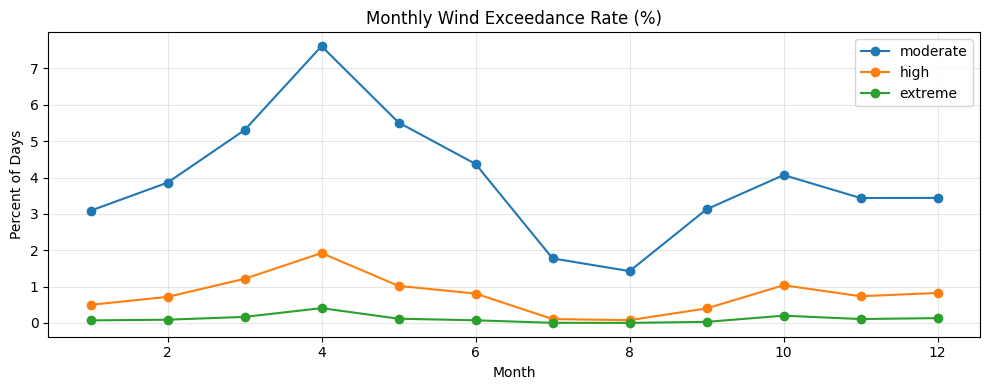

In [36]:
# Monthly climatology of exceedance rates (all points combined)
monthly = (
    wind.groupby("month")[[f"is_{k}" for k in THRESHOLDS]]
    .mean()
    .mul(100)
    .rename(columns={f"is_{k}": k for k in THRESHOLDS})
)

ax = monthly.plot(kind="line", marker="o", figsize=(10, 4))
ax.set_title("Monthly Wind Exceedance Rate (%)")
ax.set_xlabel("Month")
ax.set_ylabel("Percent of Days")
ax.grid(alpha=0.3)
plt.tight_layout()
monthly

,year,max_high_wind_streak_days
25,2015,3
26,2016,5
27,2017,4
28,2018,3
29,2019,3
30,2020,5
31,2021,3
32,2022,4
33,2023,3
34,2024,3


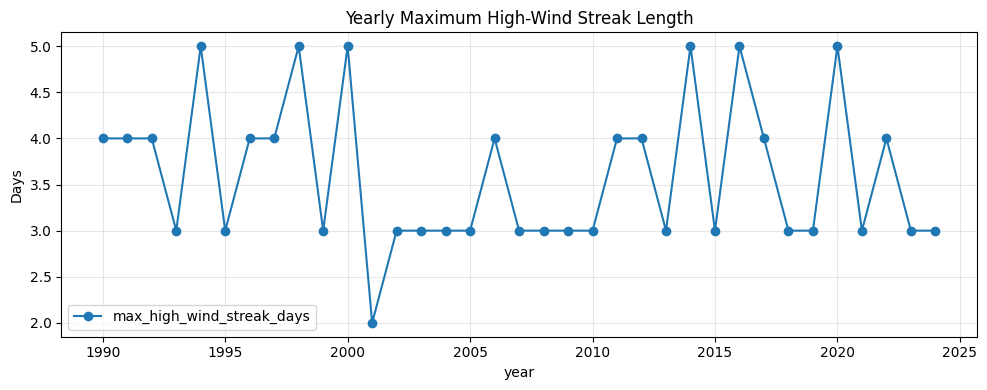

In [37]:
# Wind persistence: longest yearly streak of high-wind days (>= high threshold)
wind = wind.sort_values(["point_id", "date"]).copy()
wind["high_int"] = wind["is_high"].astype(int)

# Run-length encoding per point
wind["block"] = (
    wind.groupby("point_id")["high_int"]
    .diff()
    .fillna(0)
    .ne(0)
    .groupby(wind["point_id"])
    .cumsum()
)

streaks = (
    wind[wind["high_int"] == 1]
    .groupby(["point_id", "year", "block"], as_index=False)
    .size()
    .rename(columns={"size": "streak_len_days"})
)

yearly_streak = (
    streaks.groupby("year", as_index=False)["streak_len_days"]
    .max()
    .rename(columns={"streak_len_days": "max_high_wind_streak_days"})
)

ax = yearly_streak.plot(x="year", y="max_high_wind_streak_days", figsize=(10, 4), marker="o")
ax.set_title("Yearly Maximum High-Wind Streak Length")
ax.set_ylabel("Days")
ax.grid(alpha=0.3)
plt.tight_layout()
yearly_streak.tail(10)

In [ ]:
# Yearly trend in high-wind day frequency
yearly = (
    wind.groupby("year", as_index=False)["is_high"]
    .mean()
    .rename(columns={"is_high": "pct_high_wind_days"})
)
yearly["pct_high_wind_days"] *= 100

coef = np.polyfit(yearly["year"], yearly["pct_high_wind_days"], 1)
trend_line = np.poly1d(coef)(yearly["year"])

ax = yearly.plot(x="year", y="pct_high_wind_days", figsize=(10, 4), marker="o", label="observed")
ax.plot(yearly["year"], trend_line, linestyle="--", label=f"trend ({coef[0]:.3f} pct-pts/yr)")
ax.set_title("Trend in High-Wind Days (>= 8 m/s)")
ax.set_ylabel("Percent of Days")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

print(f"Estimated trend slope: {coef[0]:.3f} percentage points per year")
yearly.tail(10)

In [ ]:
# Optional: point-level hotspot table for operational targeting
point_hotspots = (
    wind.groupby("point_id", as_index=False)
    .agg(
        avg_ws_mps=("ws_mean", "mean"),
        p95_ws_mps=("ws_mean", lambda s: s.quantile(0.95)),
        pct_high_days=("is_high", "mean"),
        pct_extreme_days=("is_extreme", "mean"),
    )
)
point_hotspots["pct_high_days"] *= 100
point_hotspots["pct_extreme_days"] *= 100

point_hotspots.sort_values(["pct_extreme_days", "pct_high_days"], ascending=False).head(20)

### How to use this for fire danger
- Use `summary` for baseline wind hazard intensity.
- Use `monthly` to identify seasonal wind-driven fire windows.
- Use `yearly_streak` for persistence risk (multi-day drying/spread support).
- Use `yearly` + slope for long-term change detection.
- Use `point_hotspots` to prioritize zones for prevention staffing and readiness.

,point_id,count,lat,lon
0,2616,3045,37.5,-103.0
1,2617,3004,37.5,-102.9
2,2545,2847,37.6,-103.0
3,2615,2758,37.5,-103.1
4,2546,2748,37.6,-102.9
5,2618,2744,37.5,-102.8
6,2687,2718,37.4,-103.0
7,2688,2660,37.4,-102.9
8,2474,2645,37.7,-103.0
9,2544,2586,37.6,-103.1


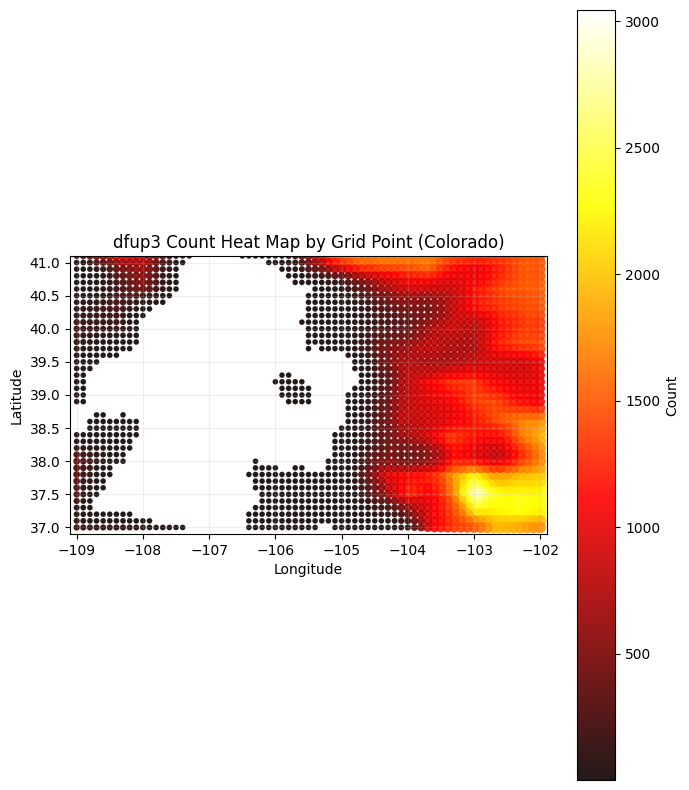

In [38]:
# Heat-map style plot: count of dfup3 records by grid point (mapped to lat/lon)
point_counts = (
    dfup3["point_id"]
    .value_counts()
    .rename_axis("point_id")
    .reset_index(name="count")
)

# Use lat/lon already attached to dfup3 when available, else fall back to latlons table
if {"lat", "lon"}.issubset(dfup3.columns):
    point_ll = dfup3[["point_id", "lat", "lon"]].drop_duplicates("point_id")
else:
    point_ll = latlons[["point_id", "lat", "lon"]].drop_duplicates("point_id")

heat = point_counts.merge(point_ll, on="point_id", how="left").dropna(subset=["lat", "lon"])

plt.figure(figsize=(7, 8))
sc = plt.scatter(
    heat["lon"],
    heat["lat"],
    c=heat["count"],
    s=15 + 85 * (heat["count"] / heat["count"].max()),
    cmap="hot",
    alpha=0.9,
    linewidths=0.1,
)
plt.colorbar(sc, label="Count")
plt.title("dfup3 Count Heat Map by Grid Point (Colorado)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Colorado bounding box
plt.xlim(-109.1, -101.9)
plt.ylim(36.9, 41.1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.2)
plt.tight_layout()

heat.sort_values("count", ascending=False).head(10)

In [42]:
dfup3['point_id'].value_counts().shape

(1893,)

In [43]:
wsmn.head()

,datetime,point_id,mean
0,19900101,0,2.388929
1,19900101,1,2.449666
2,19900101,2,2.589938
3,19900101,3,2.745264
4,19900101,4,2.865530


In [50]:
a=wsmn.groupby("point_id")['mean'].max()

In [51]:
a.head()

point_id
0     9.226524
1     9.916249
2    10.654973
3    11.380896
4    11.998657
Name: mean, dtype: float64

In [52]:
a['lat'] = a.index.map(latlons.set_index('point_id')['lat'])
a['lon'] = a.index.map(latlons.set_index('point_id')['lon'])

,point_id,lat,lon,mean_ws
0,0,41.1,-109.0,9.226524
1,1,41.1,-108.9,9.916249
2,2,41.1,-108.8,10.654973
3,3,41.1,-108.7,11.380896
4,4,41.1,-108.6,11.998657


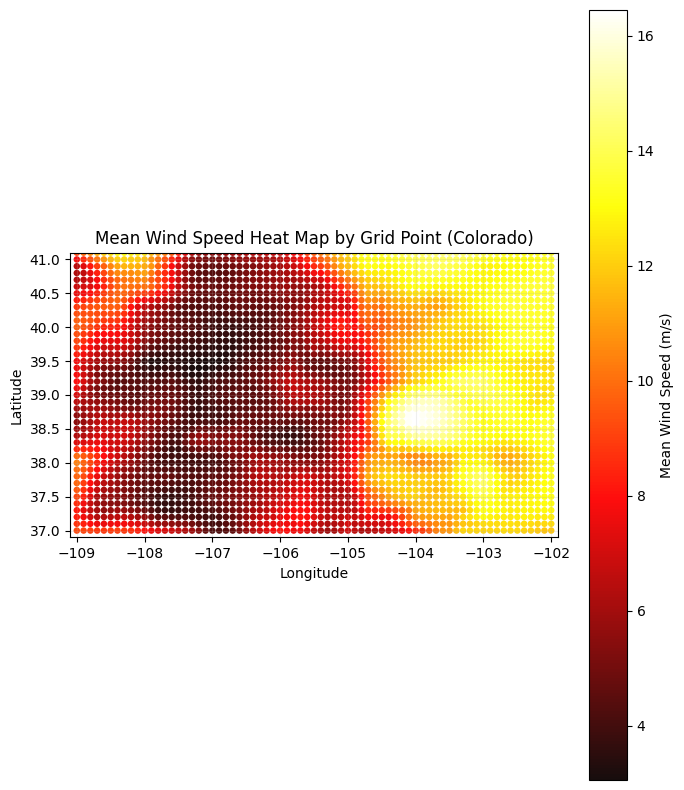

In [53]:
# Mean wind heat map by point (Colorado)
# Works whether `a` is a Series (index=point_id, values=mean wind) or a DataFrame.
if isinstance(a, pd.Series):
    mean_map = a.rename("mean_ws").reset_index()
    mean_map.columns = ["point_id", "mean_ws"]
else:
    mean_map = a.copy()
    if "mean_ws" not in mean_map.columns:
        # Fall back to common names for the mean-wind column
        if "mean" in mean_map.columns:
            mean_map = mean_map.rename(columns={"mean": "mean_ws"})
        else:
            value_cols = [c for c in mean_map.columns if c not in ["point_id", "lat", "lon"]]
            mean_map = mean_map.rename(columns={value_cols[0]: "mean_ws"})

# Ensure lat/lon exist
if not {"lat", "lon"}.issubset(mean_map.columns):
    point_ll = latlons[["point_id", "lat", "lon"]].drop_duplicates("point_id")
    mean_map = mean_map.merge(point_ll, on="point_id", how="left")

mean_map = mean_map.dropna(subset=["lat", "lon", "mean_ws"])

plt.figure(figsize=(7, 8))
sc = plt.scatter(
    mean_map["lon"],
    mean_map["lat"],
    c=mean_map["mean_ws"],
    s=22,
    cmap="hot",
    alpha=0.95,
    linewidths=0,
)
plt.colorbar(sc, label="Mean Wind Speed (m/s)")
plt.title("Mean Wind Speed Heat Map by Grid Point (Colorado)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-109.1, -101.9)
plt.ylim(36.9, 41.1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.2)
plt.tight_layout()

mean_map[["point_id", "lat", "lon", "mean_ws"]].head()

In [54]:
# Station-only wind data for Colorado: daily and monthly summaries (no model matching)
# Requires: pip install meteostat
from datetime import datetime
from meteostat import Stations, Daily

# 1) Get Colorado stations
stations = Stations().region("US", "CO").fetch(300)

# 2) Pull daily station data (adjust period as needed)
start = datetime(2000, 1, 1)
end = datetime(2024, 12, 31)

daily = Daily(stations.index, start, end).fetch()
# `daily` index is [station, time]

# Keep wind-only fields when available:
# wspd = average wind speed, wpgt = peak gust, wdir = wind direction
daily_wind = daily[[c for c in ["wspd", "wpgt", "wdir"] if c in daily.columns]].dropna(how="all")

# 3) Monthly summary from daily data
monthly_wind = (
    daily_wind.reset_index()
    .groupby(["station", pd.Grouper(key="time", freq="MS")], as_index=False)
    .agg(
        wspd_mean=("wspd", "mean"),
        wspd_p90=("wspd", lambda s: s.quantile(0.90)),
        wpgt_max=("wpgt", "max") if "wpgt" in daily_wind.columns else ("wspd", "max"),
        n_days=("wspd", "count"),
    )
)

# 4) Attach station metadata
station_meta = stations[["name", "latitude", "longitude", "elevation"]].reset_index().rename(columns={"id": "station"})
monthly_wind = monthly_wind.merge(station_meta, on="station", how="left")

print("Stations fetched:", len(stations))
print("Daily rows:", len(daily_wind), "| Monthly rows:", len(monthly_wind))

# Preview outputs
daily_wind.head(), monthly_wind.head()

ModuleNotFoundError: No module named 'meteostat'

In [20]:
df100m = pd.read_csv("/home/joe/work/Fire/ML/Data/reanalysis-era5-single-levels-timeseries-sfcvsbda1gb.csv")

In [4]:
df100.head()

,valid_time,u100,v100,latitude,longitude
0,1940-01-01 00:00:00,-2.361069,2.748428,40.0,-105.0
1,1940-01-01 01:00:00,-1.467804,3.489151,40.0,-105.0
2,1940-01-01 02:00:00,0.137741,3.369324,40.0,-105.0
3,1940-01-01 03:00:00,1.150482,2.238907,40.0,-105.0
4,1940-01-01 04:00:00,1.138275,1.340164,40.0,-105.0


In [10]:
df100['month'] = df100['valid_time'].str[5:7].astype(int)
df100['year'] = df100['valid_time'].str[:4].astype(int) 

In [11]:
df100['month'].value_counts() 

month
1     64728
3     64152
7     63984
5     63984
12    63984
10    63984
8     63984
4     61920
9     61920
6     61920
11    61920
2     58992
Name: count, dtype: int64

In [13]:
df100 = df100[df100['year'] >= 1990].copy()    

In [14]:
df100['month'].value_counts()

month
1     27528
3     26952
7     26784
5     26784
12    26784
10    26784
8     26784
4     25920
9     25920
6     25920
11    25920
2     25080
Name: count, dtype: int64

In [18]:
df100['ws'] = np.sqrt(df100['u100']**2 + df100['v100']**2)*2.237           

In [19]:
df100.groupby("month")["ws"].mean()

month
1     6.923239
2     7.022766
3     7.510012
4     8.163403
5     7.401889
6     7.108613
7     6.466023
8     6.346219
9     6.584137
10    6.881444
11    6.781151
12    6.957636
Name: ws, dtype: float64

In [21]:
df100m['month'] = df100m['valid_time'].str[5:7].astype(int)
df100m['year'] = df100m['valid_time'].str[:4].astype(int) 

In [22]:
df100m['ws'] = np.sqrt(df100m['u100']**2 + df100m['v100']**2)*2.237           


In [23]:
df100m.groupby("month")["ws"].mean()


month
1     7.206555
2     7.102915
3     7.688426
4     8.065142
5     7.376252
6     6.955499
7     6.249485
8     6.138373
9     6.649382
10    6.712932
11    6.905829
12    7.258185
Name: ws, dtype: float64

In [2]:
cl = pd.read_csv("/home/joe/work/Fire/ML/New/co_wind_climate.csv")                

In [4]:
display(cl.head(199))

,Station,Years,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year
0,AKRON REGIONAL AP (KAKO),2001-2011,11.8,12.0,13.0,14.1,12.6,11.8,11.0,11.1,11.4,11.9,11.9,11.8,12.0
1,ALAMOSA-SAN LUIS VALLEY AP (KALS),2001-2011,5.3,6.6,8.4,10.7,9.8,8.8,6.5,6.3,6.6,6.6,6.1,5.4,7.3
2,ASPEN-PITKIN COUNTY ARPT (KASE),2001-2011,4.6,5.1,5.9,6.8,6.9,6.9,6.5,6.4,6.4,5.7,4.9,4.5,5.9
3,BURLINGTON-KIT CARSON AP (KITR),2001-2011,11.3,11.9,12.8,14.0,13.2,12.3,11.2,10.9,11.6,11.7,11.7,11.4,12.0
4,COLORADO SPRINGS MUNI AP (KCOS),2001-2011,8.4,9.3,10.2,12.2,10.8,10.1,8.9,8.7,9.1,9.5,8.8,8.7,9.6
5,CORTEZ MUNICIPAL AIRPORT (KCEZ),2001-2011,5.6,6.1,7.4,8.7,8.0,7.7,6.3,5.9,6.2,6.4,6.0,5.7,6.7
6,CRAIG-MOFFAT AIRPORT (KCAG),2001-2011,3.3,4.2,5.6,7.7,6.6,6.3,5.5,5.4,5.2,5.0,4.4,3.7,5.2
7,DENVER-CENTENNIAL AIRPORT (KAPA),2001-2011,7.7,7.9,8.7,10.1,8.7,8.6,8.0,7.9,7.8,7.6,7.6,7.7,8.2
8,DENVER INTERNATIONAL AIRPORT (KDEN),2001-2011,9.7,9.7,10.7,11.8,10.5,10.1,9.5,9.6,9.4,9.6,9.6,9.6,10.0
9,DURANGO-LA PLATA CO AIRPORT (KDRO),2001-2011,4.4,5.3,6.5,7.9,7.3,6.8,6.0,5.6,5.4,5.4,4.8,4.5,5.8


In [7]:
cl.drop(columns=['Years'],axis=1, inplace=True)

In [12]:
cl.groupby(["Station"]).sum()


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year
Station,,,,,,,,,,,,,
AKRON REGIONAL AP (KAKO),11.8,12.0,13.0,14.1,12.6,11.8,11.0,11.1,11.4,11.9,11.9,11.8,12.0
ALAMOSA-SAN LUIS VALLEY AP (KALS),5.3,6.6,8.4,10.7,9.8,8.8,6.5,6.3,6.6,6.6,6.1,5.4,7.3
ASPEN-PITKIN COUNTY ARPT (KASE),4.6,5.1,5.9,6.8,6.9,6.9,6.5,6.4,6.4,5.7,4.9,4.5,5.9
BURLINGTON-KIT CARSON AP (KITR),11.3,11.9,12.8,14.0,13.2,12.3,11.2,10.9,11.6,11.7,11.7,11.4,12.0
COLORADO SPRINGS MUNI AP (KCOS),8.4,9.3,10.2,12.2,10.8,10.1,8.9,8.7,9.1,9.5,8.8,8.7,9.6
CORTEZ MUNICIPAL AIRPORT (KCEZ),5.6,6.1,7.4,8.7,8.0,7.7,6.3,5.9,6.2,6.4,6.0,5.7,6.7
CRAIG-MOFFAT AIRPORT (KCAG),3.3,4.2,5.6,7.7,6.6,6.3,5.5,5.4,5.2,5.0,4.4,3.7,5.2
DENVER INTERNATIONAL AIRPORT (KDEN),9.7,9.7,10.7,11.8,10.5,10.1,9.5,9.6,9.4,9.6,9.6,9.6,10.0
DENVER-CENTENNIAL AIRPORT (KAPA),7.7,7.9,8.7,10.1,8.7,8.6,8.0,7.9,7.8,7.6,7.6,7.7,8.2


In [9]:
cl.dtypes

Station     object
Jan        float64
Feb        float64
Mar        float64
Apr        float64
May        float64
Jun        float64
Jul        float64
Aug        float64
Sep        float64
Oct        float64
Nov        float64
Dec        float64
Year       float64
dtype: object

## Inventory ERA5 Wind Files

In [4]:
from pathlib import Path
import pandas as pd

zip_dir = Path("/home/joe/work/Fire/ERA5/Data/P25_29x17")

# 1) List zip files
zip_files = sorted(zip_dir.glob("*.zip"))
print(f"Found {len(zip_files)} zip files")
for f in zip_files:
    print(f.name)


# 2) Read each zip with pandas
data = {}
fout = open("wind_summary.csv", "a")
nfile=0
for zf in zip_files:
    df = pd.read_csv(zf, compression="zip")  # assumes one CSV per zip
    nfile+=1 
    lat=df['latitude'].unique()[0]
    lon=df['longitude'].unique()[0]
    start=df['valid_time'].min() 
    end=df['valid_time'].max() 
    nrows = df.shape[0]
    print(f"{nfile} of {len(zip_files)},{lat},{lon},{start},{end},{nrows}\n")
    fout.write(f"{lat},{lon},{start},{end},{nrows}\n")
    
fout.close()

1 of 493,41.0,-104.5,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

2 of 493,40.5,-106.75,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

3 of 493,39.0,-103.75,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

4 of 493,37.0,-103.5,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

5 of 493,37.25,-106.25,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

6 of 493,37.75,-103.5,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

7 of 493,37.25,-107.5,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

8 of 493,39.0,-104.0,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

9 of 493,40.25,-105.25,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

10 of 493,40.0,-109.0,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

11 of 493,38.0,-107.0,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

12 of 493,40.0,-103.5,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

13 of 493,40.5,-108.25,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

14 of 493,37.0,-105.75,1940-01-01 00:00:00,2026-03-07 23:00:00,755472

15 of 493,39.5,-107

In [7]:
df= pd.read_csv("wind_summary.csv", names =["latitude","longitude","start_time","end_time","nrows"])
x = 41
y=-109 
np=0
points={}
lats = []
lons = []
while x >=  37:
    lats.append(x)
    x-=.25

while y <= -102:
    lons.append(y)
    y+=.25

elats = df['latitude'].unique()
elons = df['longitude'].unique()
set(lats) - set(elats) 
set(lons) - set(elons)
set(elats) - set(lats)
set(elons) - set(lons)


## Compute Wind Speed for 29x17 Grid

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import sqlite3

zip_dir = Path("/home/joe/work/Fire/ERA5/Data/P25_29x17")
sqlite_path = Path("/home/joe/work/Fire/ML/New/era5_wind_29x17.sqlite")
table_name = "wind_100m"

zip_files = sorted(zip_dir.glob("*.zip"))
print(f"Found {len(zip_files)} zip files")
if not zip_files:
    raise ValueError(f"No zip files found in {zip_dir}")

create_sql = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
    latitude REAL NOT NULL,
    longitude REAL NOT NULL,
    valid_time TEXT NOT NULL,
    u100 REAL,
    v100 REAL,
    ws100 REAL,
    PRIMARY KEY (latitude, longitude, valid_time)
);
"""

insert_sql = f"""
INSERT OR IGNORE INTO {table_name}
(latitude, longitude, valid_time, u100, v100, ws100)
VALUES (?, ?, ?, ?, ?, ?)
"""

rows_attempted = 0
rows_inserted = 0

with sqlite3.connect(sqlite_path) as conn:
    conn.execute(create_sql)

    for i, zf in enumerate(zip_files, start=1):
        df = pd.read_csv(zf, compression="zip")  # assumes one CSV per zip

        required = ["latitude", "longitude", "valid_time", "u100", "v100"]
        missing = [c for c in required if c not in df.columns]
        if missing:
            raise ValueError(f"{zf.name} missing required columns: {missing}")

        df["valid_time"] = pd.to_datetime(df["valid_time"], errors="coerce")
        df = df.dropna(subset=["valid_time"]).copy()
        df = df.loc[df["valid_time"].dt.year >= 1990].copy()
        df["valid_time"] = df["valid_time"].dt.strftime("%Y-%m-%d-%H")
        df["ws100"] = np.sqrt(df["u100"]**2 + df["v100"]**2)

        df = df[["latitude", "longitude", "valid_time", "u100", "v100", "ws100"]]
        df = df.drop_duplicates(subset=["latitude", "longitude", "valid_time"])

        rows = list(df.itertuples(index=False, name=None))
        before = conn.total_changes
        conn.executemany(insert_sql, rows)
        inserted_now = conn.total_changes - before

        rows_attempted += len(df)
        rows_inserted += inserted_now

        if i % 25 == 0 or i == len(zip_files):
            print(
                f"{i}/{len(zip_files)} files | "
                f"attempted: {rows_attempted:,} | inserted: {rows_inserted:,}"
            )

        conn.commit()

print(f"Done. SQLite file: {sqlite_path}")
print(f"Table: {table_name} (PK: latitude, longitude, valid_time)")
print(f"Rows attempted: {rows_attempted:,}")
print(f"Rows inserted (new only): {rows_inserted:,}")

## Compute Monthly Means

In [ ]:
import sqlite3
from pathlib import Path
import pandas as pd
sqlite_path = Path("/home/joe/work/Fire/ML/New/era5_wind_29x17.sqlite")
table_name = "wind_100m"
latlons = pd.read_csv("latlons_17x29.csv")
sqlite_path_out = Path("/home/joe/work/Fire/ML/New/Data/DB/era5_wind_means_29x17.sqlite")
table_name_out = "wind_mean_100m"

create_sql = f"""
CREATE TABLE IF NOT EXISTS {table_name_out} (
    latitude REAL NOT NULL,
    longitude REAL NOT NULL,
    yrmo DATE NOT NULL,
    ws100 REAL,
    cnt_20mph INTEGER,
    cnt_25mph INTEGER,
    PRIMARY KEY (latitude, longitude, yrmo)
);
"""

## Create table if it does not exist
with sqlite3.connect(sqlite_path_out) as conn:
    conn.execute(create_sql)



In [ ]:



with sqlite3.connect(sqlite_path) as conn:
    npoints = len(latlons)
    for i, row in latlons.iterrows():
        lat = row['latitude']
        lon = row['longitude']
        sample = pd.read_sql_query(f"SELECT * FROM {table_name} where latitude = {lat} and longitude = {lon}", conn)
    #  sample = pd.read_sql_query(f"SELECT * FROM {table_name} where valid_time < '1990-01-04-00'", conn)
        print(f"{i+1}/{npoints} Processing lat {lat}, lon {lon} with {len(sample)} records")  

        sample['yyyymmdd'] = sample['valid_time'].str[:10]  
        dates=[]
        wss=[]
        cnts0=[]
        cnts5=[]
        for gp in sample.groupby('yyyymmdd'):
            men=round(gp[1]['ws100'].mean()*2.23694,1)
            cnt0 =gp[1][gp[1]['ws100']*2.23694 >= 20.0]['ws100'].count()
            cnt5 =gp[1][gp[1]['ws100']*2.23694 >= 25.0]['ws100'].count()
            dates.append(gp[0])
            wss.append(men)
            cnts0.append(cnt0)
            cnts5.append(cnt5)        

        dfOut = pd.DataFrame({
            "date": dates,
            "ws100": wss,
            "cnt_20mph": cnts0,
            "cnt_25mph": cnts5
        })  
        dfOut['latitude'] = lat
        dfOut['longitude'] = lon
        dfOut['yrmo'] = dfOut['date'].str[:7]
        out = (
            dfOut.groupby(["yrmo"], as_index=False)
            .agg({
                "ws100": "mean",
                "cnt_20mph": "sum",
                "cnt_25mph": "sum"
            })
        )
        out['yrmo'] = out['yrmo'] + "-01"  # Convert "YYYY-MM" to "YYYY-MM-01" for DATE type
        out['latitude'] = lat
        out['longitude'] = lon

        with sqlite3.connect(sqlite_path_out) as conn2:
            out.to_sql(table_name_out, conn2, index=False, if_exists='append')
    

In [ ]:
with sqlite3.connect(sqlite_path_out) as conn2:
    df = pd.read_sql("select * from ")

In [14]:
sample['yyyymmdd'] = sample['valid_time'].str[:10]  
dates=[]
wss=[]
cnts0=[]
cnts5=[]
for gp in sample.groupby('yyyymmdd'):
    men=round(gp[1]['ws100'].mean()*2.23694,1)
    cnt0 =gp[1][gp[1]['ws100']*2.23694 >= 20.0]['ws100'].count()
    cnt5 =gp[1][gp[1]['ws100']*2.23694 >= 25.0]['ws100'].count()
    dates.append(gp[0])
    wss.append(men)
    cnts0.append(cnt0)
    cnts5.append(cnt5)        
    print(gp[0],men,cnt0,cnt5)

dfOut = pd.DataFrame({
    "date": dates,
    "ws100": wss,
    "cnt_20mph": cnts0,
    "cnt_25mph": cnts5
})  
dfOut['latitude'] = lat
dfOut['longitude'] = lon
dfOut['yrmo'] = dfOut['date'].str[:7]
out = (
    dfOut.groupby(["yrmo"], as_index=False)
      .agg({
          "ws100": "mean",
          "cnt_20mph": "sum",
          "cnt_25mph": "sum"
      })
)
out['yrmo'] = out['yrmo'] + "-01"  # Convert "YYYY-MM" to "YYYY-MM-01" for DATE type
out['latitude'] = lat
out['longitude'] = lon


with sqlite3.connect(sqlite_path_out) as conn2:
    out.to_sql(table_name_out, conn2, index=False, if_exists='append')
    

1990-01-01 10.1 0 0
1990-01-02 15.4 3 0
1990-01-03 17.8 1 0
1990-01-04 10.8 0 0
1990-01-05 13.2 0 0
1990-01-06 7.0 0 0
1990-01-07 7.8 0 0
1990-01-08 13.0 1 0
1990-01-09 11.6 4 0
1990-01-10 10.0 0 0
1990-01-11 6.8 0 0
1990-01-12 6.4 0 0
1990-01-13 10.3 0 0
1990-01-14 10.6 0 0
1990-01-15 5.8 0 0
1990-01-16 6.0 0 0
1990-01-17 5.1 0 0
1990-01-18 6.0 0 0
1990-01-19 11.5 0 0
1990-01-20 8.8 0 0
1990-01-21 7.8 0 0
1990-01-22 8.3 0 0
1990-01-23 10.8 0 0
1990-01-24 20.8 13 3
1990-01-25 14.2 1 0
1990-01-26 12.8 0 0
1990-01-27 15.9 5 1
1990-01-28 10.8 0 0
1990-01-29 12.8 4 0
1990-01-30 14.0 2 0
1990-01-31 9.9 0 0
1990-02-01 6.1 0 0
1990-02-02 17.1 12 0
1990-02-03 11.2 0 0
1990-02-04 12.3 0 0
1990-02-05 7.1 0 0
1990-02-06 7.9 0 0
1990-02-07 13.6 0 0
1990-02-08 10.6 0 0
1990-02-09 8.9 0 0
1990-02-10 12.6 1 0
1990-02-11 13.8 4 0
1990-02-12 11.3 0 0
1990-02-13 9.1 0 0
1990-02-14 10.3 0 0
1990-02-15 11.3 0 0
1990-02-16 10.0 0 0
1990-02-17 17.3 11 0
1990-02-18 5.6 0 0
1990-02-19 7.8 0 0
1990-02-20 11.3 

In [6]:
sqlite_path_out = Path("/home/joe/work/Fire/ML/New/Data/DB/era5_wind_means_29x17.sqlite")
table_name_out = "wind_mean_100m"
with sqlite3.connect(sqlite_path_out) as conn2:
    chk = pd.read_sql_query(f"SELECT * FROM {table_name_out}", conn2)
    print(chk.head(100))


    latitude  longitude        yrmo      ws100  cnt_20mph  cnt_25mph
0       37.0     -109.0  1990-01-01   8.370968         10          0
1       37.0     -109.0  1990-02-01  11.439286         67         18
2       37.0     -109.0  1990-03-01   9.106452         32          9
3       37.0     -109.0  1990-04-01  10.443333         61         16
4       37.0     -109.0  1990-05-01  11.787097         78         25
..       ...        ...         ...        ...        ...        ...
95      37.0     -109.0  1997-12-01   8.574194          5          0
96      37.0     -109.0  1998-01-01   7.580645          3          0
97      37.0     -109.0  1998-02-01  10.150000         47         23
98      37.0     -109.0  1998-03-01   9.464516         46          9
99      37.0     -109.0  1998-04-01  10.536667         56         18

[100 rows x 6 columns]


In [11]:
chk.shape

(214455, 6)

In [12]:
chk.head()

,latitude,longitude,yrmo,ws100,cnt_20mph,cnt_25mph
0,37.0,-109.0,1990-01-01,8.370968,10,0
1,37.0,-109.0,1990-02-01,11.439286,67,18
2,37.0,-109.0,1990-03-01,9.106452,32,9
3,37.0,-109.0,1990-04-01,10.443333,61,16
4,37.0,-109.0,1990-05-01,11.787097,78,25


In [13]:
lls = pd.read_csv("latlons_17x29_points.csv")

In [19]:
chk=pd.merge(chk, lls, on=['latitude', 'longitude'],how='left')

In [23]:
chk['point'].value_counts()

point
28     435
464    435
465    435
466    435
467    435
      ... 
480    435
481    435
482    435
483    435
484    435
Name: count, Length: 493, dtype: int64

In [25]:
sqlite_path_out = Path("/home/joe/work/Fire/ML/New/Data/DB/era5_wind_means_29x17.sqlite")
table_name_out = "wind_mean_100m_points"
create_sql = f"""
CREATE TABLE IF NOT EXISTS {table_name_out} (
    point_id INTEGER NOT NULL,
    latitude REAL NOT NULL,
    longitude REAL NOT NULL,
    yrmo DATE NOT NULL,
    ws100 REAL,
    cnt_20mph INTEGER,
    cnt_25mph INTEGER,
    PRIMARY KEY (point_id, yrmo)
);
"""



with sqlite3.connect(sqlite_path_out) as conn:
    conn.execute(create_sql)


In [27]:
chk.rename(columns={"point": "point_id"}, inplace=True)
with sqlite3.connect(sqlite_path_out) as conn:
    chk.to_sql(table_name_out, conn, index=False, if_exists='append')

In [28]:
with sqlite3.connect(sqlite_path_out) as conn2:
    chk = pd.read_sql_query(f"SELECT * FROM {table_name_out}", conn2)   

In [29]:
chk.head()

,point_id,latitude,longitude,yrmo,ws100,cnt_20mph,cnt_25mph
0,464,37.0,-109.0,1990-01-01,8.370968,10,0
1,464,37.0,-109.0,1990-02-01,11.439286,67,18
2,464,37.0,-109.0,1990-03-01,9.106452,32,9
3,464,37.0,-109.0,1990-04-01,10.443333,61,16
4,464,37.0,-109.0,1990-05-01,11.787097,78,25
